<img src="Images/Madrigal Logo.png" width="100%" align="center" />

# MADRIGAL ELECTROMOTIVES LOWEST RISK AIRCRAFT ANALYSIS

> **Author**: Ngundo Muithya

> **Email**: ngundolarrymuithya@gmail.com

# 1. Introduction

## Business Problem

The company is looking to diversify their portfolio by expanding into the aviation industry. Specifically, we are interested in buying new airplanes for the company to use in public and private enterprises.

It is my job as chief data scientist of Madrigal Electromotives to recommend the best airplanes for the company to buy. I will use data provided by safety authorities on various aircraft to determine the safest aircraft for the company to use.

## The Data

The data is a csv file from the National Transport Safety Board and includes aviation accident data from 1962 to 2023 about civil aviation accidents and selected incidents in the United Sates and international waters.

# 2. Exploratory Data Analysis

In this section I will look at the dataset and find key features and insights.

I will first import the relevant pandas package with its alias and then read the csv file.

## a) Import Pandas and read the csv file

In [2]:
import pandas as pd

aviation_df = pd.read_csv('Data/Aviation_Data.csv')
aviation_df.head()

/tmp/ipykernel_117443/1899605663.py:3: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  aviation_df = pd.read_csv('Data/Aviation_Data.csv')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


## b) EDA

In this section I will perform Exploratory Data Analysis to try and find key metrics and columns of interest.

I will start by looking at how many rows and columns there are.

In [3]:
aviation_df.shape

(90348, 31)

From this I can see that there are 90,348 records with 31 columns. Taking a look at the columns:

In [4]:
aviation_df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

Since my main priority is identifying the safest aircraft for The Company I will focus on these 10 columns:
* 'Investigation.Type'
* 'Injury.Severity'
* 'Aircraft.damage'
* 'Registration.Number'
* 'Total.Fatal.Injuries'
* 'Total.Serious.Injuries'
* 'Total.Minor.Injuries'
* 'Total.Uninjured'
* 'Weather.Condition'
* 'Broad.phase.of.flight'

I will continue to explore the dataset:

In [5]:
aviation_df.isna().sum()

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40216
Airport.Name              37644
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2841
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8555
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7843
Publication.Date          16689
dtype: i

30 of the 31 columns have null values. I will try and drop them.

In [6]:
aviation_df.dropna()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date


When I try dropping the null values from the entire dataset, I am left with no values. It appears that all the rows within the dataset have at least one missing value.

In [7]:
aviation_df['Aircraft.Category'].value_counts()

Aircraft.Category
Airplane             27617
Helicopter            3440
Glider                 508
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 14
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

From the output above, I realized that the dataset contains info on numerous aircraft categories from balloons to gyrocraft. The company is not interested in these, only airplanes. Therefore I will trim my dataset so that we only focus on airplanes. 

In [8]:
airplane_dataset = aviation_df.loc[aviation_df['Aircraft.Category'] == 'Airplane']
airplane_dataset

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,1.0,0.0,IMC,Cruise,Probable Cause,02-01-1983
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,Personal,NaN,1.0,0.0,0.0,0.0,IMC,Takeoff,Probable Cause,02-01-1983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90328,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,14-12-2022
90332,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,Personal,SKY WEST AVIATION INC TRUSTEE,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90335,20221219106475,Accident,WPR23LA069,2022-12-15,"Wichita, KS",United States,373829N,0972635W,ICT,WICHITA DWIGHT D EISENHOWER NT,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,19-12-2022
90336,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,Personal,GERBER RICHARD E,0.0,1.0,0.0,0.0,VMC,NaN,NaN,23-12-2022


I will use this dataset going forward.

I will try dropping the null values for the airplane dataset.

In [9]:
airplane_dataset.dropna()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date


I am again left with no records.

I will try trimming my dataset further by focusing only on the columns of interest I identified earlier.

In [10]:
# I started by storing the main columns in a list
main_columns = ['Investigation.Type', 'Injury.Severity', 
                'Aircraft.damage', 'Registration.Number', 
                'Total.Fatal.Injuries', 'Total.Serious.Injuries', 
                'Total.Minor.Injuries', 'Total.Uninjured', 
                'Weather.Condition', 'Broad.phase.of.flight']

main_dataset = airplane_dataset[main_columns]
main_dataset.isna().sum()

Investigation.Type            0
Injury.Severity             814
Aircraft.damage            1282
Registration.Number         235
Total.Fatal.Injuries       3165
Total.Serious.Injuries     3224
Total.Minor.Injuries       2878
Total.Uninjured             900
Weather.Condition          3053
Broad.phase.of.flight     21209
dtype: int64

I will drop the null values from this main dataset and see what I get.

In [11]:
main_subset_df = main_dataset.dropna()
main_subset_df

,Investigation.Type,Injury.Severity,Aircraft.damage,Registration.Number,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
7,Accident,Non-Fatal,Substantial,N2482N,0.0,0.0,0.0,2.0,VMC,Takeoff
8,Accident,Non-Fatal,Substantial,N7967Q,0.0,0.0,0.0,2.0,IMC,Landing
12,Accident,Non-Fatal,Destroyed,N14779,0.0,0.0,1.0,0.0,IMC,Cruise
13,Accident,Fatal(1),Destroyed,N758SK,1.0,0.0,0.0,0.0,IMC,Takeoff
14,Accident,Fatal(1),Destroyed,N4876K,1.0,0.0,0.0,0.0,IMC,Cruise
...,...,...,...,...,...,...,...,...,...,...
63869,Accident,Non-Fatal,Substantial,C-FMKB,0.0,0.0,1.0,9.0,VMC,Takeoff
63891,Accident,Non-Fatal,Substantial,N9412X,0.0,0.0,0.0,1.0,VMC,Takeoff
63893,Accident,Non-Fatal,Substantial,N5875Q,0.0,0.0,2.0,0.0,VMC,Takeoff
63896,Incident,Incident,Minor,N47BC,0.0,0.0,0.0,4.0,VMC,Climb


I now have a dataset that contains all the non-null airplane records from the dataset with the columns of interest. This is just what I need.

I have a theory that accidents tend to be more fatal than incidents for airplanes. To test it out, I will group the total number of fatalities reported per investigation type:

In [12]:
investigation_type_fatalities = main_subset_df.groupby('Investigation.Type')['Total.Fatal.Injuries'].sum().sort_values(ascending=False)

investigation_type_fatalities

Investigation.Type
Accident    1305.0
Incident       0.0
Name: Total.Fatal.Injuries, dtype: float64

It appears all the fatalities are from accidents not incidents. Therefore, the more accidents an aircraft is involved in the more dangerous it is to use. An airplane with many incidents can be safely ignored for now.

## c) Data Analysis

EDA left me with my main subset that contains all the airplane records with non-null values while focusing on key columns. I want to group my data by the registration number of the aircraft to see the number of accidents and incidents by aircraft.

In [13]:
investigation_table = main_subset_df.groupby('Registration.Number')['Investigation.Type'].value_counts().unstack(fill_value=0)
investigation_table = investigation_table.sort_values(by='Accident', ascending=False)
investigation_table

Investigation.Type,Accident,Incident
Registration.Number,,
N6409M,2,0
N4246T,2,0
N757PF,2,0
N6265P,2,0
N93286,2,0
...,...,...
N114GA,0,1
N10AY,0,1
N104WA,0,1


The most number of accidents is 2. I want airplanes that have been involved in no accidents. I will trim my subset to get just that.

> **Note**: As shown before, incidents tend to be less severe than accidents therefore I will tolerate aircraft with a high number of incidents but **NO** accidents.

In [14]:
safe_airplanes = investigation_table.loc[investigation_table['Accident'] == 0].sort_values(by='Incident', ascending=False)
safe_airplanes

Investigation.Type,Accident,Incident
Registration.Number,,
N95WA,0,1
N9361E,0,1
N9240N,0,1
N919RW,0,1
N88694,0,1
...,...,...
N114GA,0,1
N10AY,0,1
N104WA,0,1


I am now left with 91 airplanes that have been involved in 0 accidents. The most number of incidents any of them have been involved in is 1 which is good.

> **Note**: I cannot have an airplane with 0 accidents and 0 incidents since such an airplane would not have been recorded in the dataset in the first place. I am therefore willing to tolerate 1 incident since this is the least number of incidents possible that the airplanes in this dataset could have been involved in.

I will now trim, from the main airplanes subset and from the overall dataset, the safe airplanes in order to get only their details.

> Moving forward I will use the trimmed dataset on safe airplanes. The relevance of the full dataset on safe airplanes will be clear later.

In [15]:
safe_airplanes_trimmed_df = main_subset_df.loc[main_subset_df['Registration.Number'].isin(safe_airplanes.index)]
safe_airplanes_full_df = aviation_df.loc[aviation_df['Registration.Number'].isin(safe_airplanes.index)]
safe_airplanes_trimmed_df

,Investigation.Type,Injury.Severity,Aircraft.damage,Registration.Number,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
23,Incident,Incident,Minor,N5018P,0.0,0.0,0.0,1.0,VMC,Approach
40,Incident,Incident,Minor,N5782N,0.0,0.0,0.0,1.0,VMC,Cruise
80,Incident,Incident,Minor,N615KC,0.0,0.0,0.0,2.0,VMC,Taxi
119,Incident,Incident,Minor,N9240N,0.0,0.0,0.0,1.0,IMC,Descent
131,Incident,Incident,Minor,N74HP,0.0,0.0,0.0,2.0,VMC,Takeoff
...,...,...,...,...,...,...,...,...,...,...
3557,Incident,Incident,Minor,N6810,0.0,0.0,0.0,58.0,IMC,Go-around
59584,Incident,Incident,Minor,N536JB,0.0,0.0,0.0,146.0,VMC,Takeoff
62912,Incident,Incident,Minor,N105GC,0.0,0.0,0.0,1.0,VMC,Cruise
63182,Incident,Incident,Minor,N3120T,0.0,0.0,0.0,1.0,VMC,Descent


I will now check to see the total number of minor injuries per airplane to find even safer airplanes. A low number of minor injuries means the plane's design maximises peoples' chances of survival which means a safer plane.

In [16]:
minor_injuries_series = safe_airplanes_trimmed_df.groupby('Registration.Number')['Total.Minor.Injuries'].sum().sort_values()
minor_injuries_series

Registration.Number
N101RA     0.0
N104WA     0.0
N105GC     0.0
N10AY      0.0
N114GA     0.0
          ... 
N50DA      1.0
N1969J     1.0
N9361E     1.0
N7043Z     1.0
N7345F    33.0
Name: Total.Minor.Injuries, Length: 91, dtype: float64

Scrolling down, I can see that there are 5 planes that had injuries as a result of the incident they were involved in. These are clearly not that safe compared to those that had 0 minor injuries.

I will take this further and look at the uninjured per airplane. A high number of uninjured means a safer airplane.

In [17]:
uninjured_series = safe_airplanes_trimmed_df.groupby('Registration.Number')['Total.Uninjured'].sum().sort_values(ascending=False)
uninjured_series

Registration.Number
N104WA    393.0
N333EA    152.0
N536JB    146.0
N64323    129.0
N73717    119.0
          ...  
N9240N      1.0
N1969J      0.0
N7043Z      0.0
N7345F      0.0
N9361E      0.0
Name: Total.Uninjured, Length: 91, dtype: float64

Combining these two will enable me to find *super* safe aircraft that have a low number of minor injuries and a high number of uninjured for the incident they were involved in:

In [18]:
search_limit = 40
super_safe_airplanes = [reg_no for reg_no in minor_injuries_series.head(search_limit).index if reg_no in uninjured_series.head(search_limit).index]
print(len(super_safe_airplanes))
super_safe_airplanes

13


['N101RA',
 'N104WA',
 'N114GA',
 'N1500E',
 'N201WX',
 'N222SA',
 'N2233Q',
 'N23BX',
 'N25973',
 'N26210',
 'N323BA',
 'N33226',
 'N333EA']

Looking at the top 40 planes in `minor_injuries_series`, we can find 13 airplanes that are also in the top 40 of `uninjured_series` with the airplane 'N101RA' being the safest. These represent very safe aircraft with very low chances of injuries if they were to be involved in an accident/incident. I will save the registration number 'N101RA' as the safest airplane.

> `search_limit` can be tweaked to find the planes that are in the top `search_limit` of both series.

In [19]:
safest_airplane_reg_no = 'N101RA'

I will now trim, from the main airplanes subset and overall, full dataset, the super safe airplanes to obtain their details:

In [20]:
super_safe_airplanes_trimmed_df = main_subset_df.loc[main_subset_df['Registration.Number'].isin(super_safe_airplanes)]
super_safe_airplanes_full_df = aviation_df.loc[aviation_df['Registration.Number'].isin(super_safe_airplanes)]
super_safe_airplanes_full_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
346,20020917X02630,Incident,SEA82IA029,1982-02-18,"BOISE, ID",United States,NaN,NaN,BOI,BOISE AIR TERMINAL,...,Unknown,"Cascade Airways, Inc.",0.0,0.0,0.0,16.0,VMC,Takeoff,Probable Cause,18-02-1983
515,20020917X01899,Incident,CHI82IA082,1982-03-09,"SOUTH BEND, IN",United States,NaN,NaN,SBN,MICHIANA REGIONAL,...,Unknown,"Britt Airways, Inc",0.0,0.0,0.0,9.0,UNK,Maneuvering,Probable Cause,09-03-1983
532,20020917X02572,Incident,NYC82IA051,1982-03-11,"FLUSHING, NY",United States,NaN,NaN,LGA,LAGUARDIA (R/W 22),...,Unknown,"Ransome Airlines, Inc",0.0,0.0,0.0,30.0,IMC,Climb,Probable Cause,11-03-1983
737,20020917X01902,Incident,CHI82IA112,1982-04-02,"DETROIT, MI",United States,NaN,NaN,DTW,DETROIT METRO,...,Executive/corporate,NaN,0.0,0.0,0.0,8.0,VMC,Taxi,Probable Cause,02-04-1983
908,20020917X02421,Incident,MIA82IA102,1982-04-20,"MIAMI, FL",United States,NaN,NaN,MIA,MIAMI INTERNATIONAL,...,Unknown,"Eastern Airlines, Inc.",0.0,0.0,0.0,152.0,VMC,Landing,Probable Cause,20-04-1983
1172,20020917X03894,Incident,MKC82IA079,1982-05-13,"ST. LOUIS, MO",United States,NaN,NaN,STL,LAMBERT-ST. LOUIS INTL,...,Unknown,Trans Mo Airlines,0.0,0.0,0.0,8.0,VMC,Taxi,Probable Cause,13-05-1983
1250,20020917X03236,Incident,DEN82IA090,1982-05-18,"GILLETTE, WY",United States,NaN,NaN,GCC,GILLETTE-CAMPBELL COUNTY,...,Unknown,"U.s. Aviation, Inc./air U.s.,",0.0,0.0,0.0,21.0,VMC,Landing,Probable Cause,18-05-1983
1362,20020917X03511,Incident,FTW82IA209,1982-05-28,"LAKE CHARLES, LA",United States,NaN,NaN,NaN,NaN,...,Executive/corporate,NaN,0.0,0.0,0.0,7.0,VMC,Cruise,Probable Cause,28-05-1983
1638,20020917X02894,Incident,ATL82IA170,1982-06-20,"DAUPHIN ISLAND, AL",United States,NaN,NaN,4R9,DAUPHIN ISLAND,...,Personal,NaN,0.0,0.0,0.0,4.0,VMC,Go-around,Probable Cause,20-06-1983
1957,20020917X02895,Incident,ATL82IA198,1982-07-15,"NEAR SPARTA, GA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,0.0,4.0,IMC,Cruise,Probable Cause,15-07-1983


I now have four dataframes:

* `safe_airplanes_trimmed_df`: This holds the trimmed details (non-null relevant columns only) of the safe airplanes; that is the airplanes that have been involved in 0 accidents.

* `safe_airplanes_full_df`: This holds the full details (all columns null and non-null) of the safe airplanes.

* `super_safe_airplanes_trimmed_df`: This holds the trimmed details of the super safe airplanes; that is the airplanes that have been involved in 0 accidents and have few minor injuries and many uninjured.

* `super_safe_airplanes_full_df`: This holds the full details of the super safe airplanes.


I will now write them into separate CSVs for storage.

In [21]:
safe_airplanes_trimmed_df.to_csv('Data/safe_airplanes_trimmed.csv', index=False)
safe_airplanes_full_df.to_csv('Data/safe_airplanes_full.csv', index=False)
super_safe_airplanes_trimmed_df.to_csv('Data/super_safe_airplanes_trimmed.csv', index=False)
super_safe_airplanes_full_df.to_csv('Data/super_safe_airplanes_full.csv', index=False)

# 2. Visualizations

In this section we will do some visualizations to compare relevant data.

I will look at the trimmed dataset on safe airplanes I created:

In [22]:
safe_airplanes_trimmed_df

,Investigation.Type,Injury.Severity,Aircraft.damage,Registration.Number,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
23,Incident,Incident,Minor,N5018P,0.0,0.0,0.0,1.0,VMC,Approach
40,Incident,Incident,Minor,N5782N,0.0,0.0,0.0,1.0,VMC,Cruise
80,Incident,Incident,Minor,N615KC,0.0,0.0,0.0,2.0,VMC,Taxi
119,Incident,Incident,Minor,N9240N,0.0,0.0,0.0,1.0,IMC,Descent
131,Incident,Incident,Minor,N74HP,0.0,0.0,0.0,2.0,VMC,Takeoff
...,...,...,...,...,...,...,...,...,...,...
3557,Incident,Incident,Minor,N6810,0.0,0.0,0.0,58.0,IMC,Go-around
59584,Incident,Incident,Minor,N536JB,0.0,0.0,0.0,146.0,VMC,Takeoff
62912,Incident,Incident,Minor,N105GC,0.0,0.0,0.0,1.0,VMC,Cruise
63182,Incident,Incident,Minor,N3120T,0.0,0.0,0.0,1.0,VMC,Descent


Let us look at the number of incidents per weather condition for the safe airplanes.

We can show this in a bar graph:

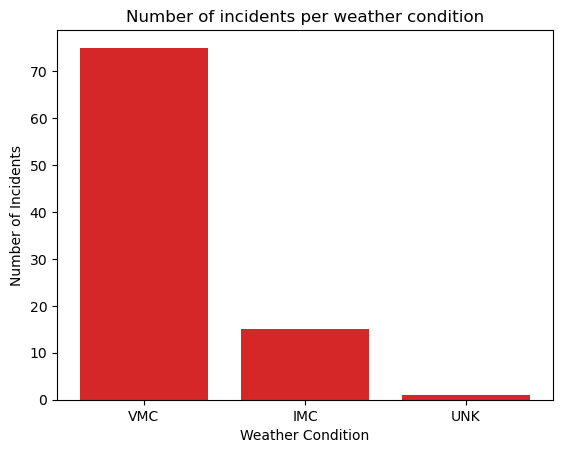

In [33]:
import matplotlib.pyplot as plt

unsafe_weather_conditions = safe_airplanes_trimmed_df['Weather.Condition'].value_counts()

# Since I will be plotting a lot I will create a function for plotting
def plot(series, x_label, y_label, title, x_ticks_rotation):

    fig, ax = plt.subplots()

    ax.bar(series.index, series.values, color='tab:red')

    if x_ticks_rotation:
        plt.xticks(rotation=90)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

    return plt.show()

plot(unsafe_weather_conditions, "Weather Condition", "Number of Incidents", "Number of incidents per weather condition", False)

Let us also look at the number of **accidents** for every weather condition.

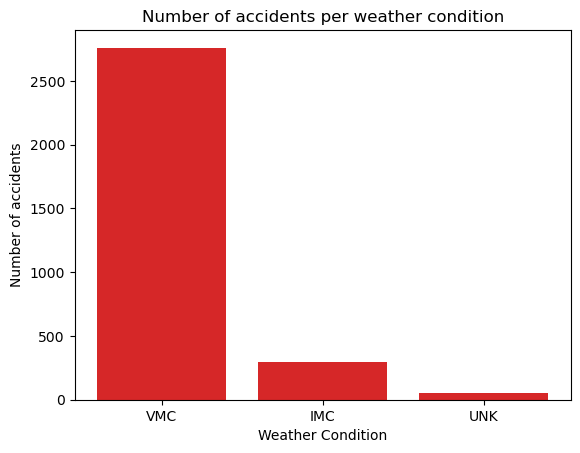

In [34]:
# Isolate airplanes that were involved in accidents
accident_airplanes = main_subset_df.loc[main_subset_df['Investigation.Type'] == 'Accident']

weather_accident_count = accident_airplanes['Weather.Condition'].value_counts()

plot(weather_accident_count, "Weather Condition", "Number of accidents", "Number of accidents per weather condition", False)

The deadliest weather condition (whether for accidents or incidents) to fly the safe airplanes in is **VMC**. This is important information to relay to the pilots should the company buy the airplanes.

I will look now at the most unsafe phase of flight for the safe airplanes.

> **Note**: No need to import `matplotlib` again as it was already imported in the previous code cell.

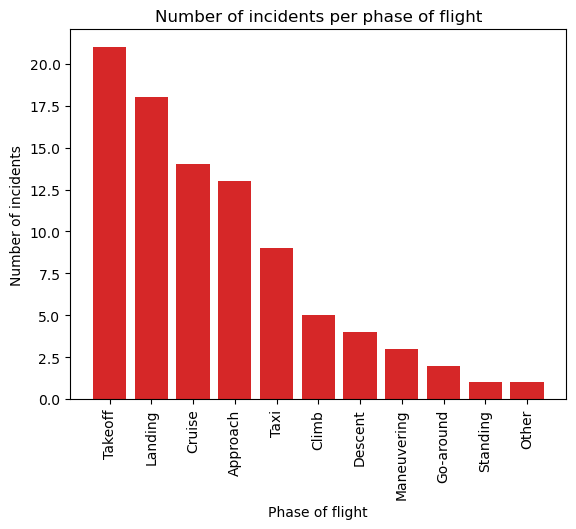

In [24]:
unsafe_phases_of_flight = safe_airplanes_trimmed_df['Broad.phase.of.flight'].value_counts()

plot(unsafe_phases_of_flight, "Phase of flight", "Number of incidents", "Number of incidents per phase of flight", True)

Should the company buy the airplanes, the phase of flight the pilots need to be most focused on is **takeoff**.

Next, I will identify which make and model of airplane is best to use by looking at how many times they appear in the safe airplanes dataset. 

> **Note**: Appearing more does not necessarily mean that the airplane is more safe since the dataset contains airplanes that have been involved in incidents. The less they appear, the less incidents they are a part of and hence the safer they are.

In [25]:
safest_makes_and_models = safe_airplanes_full_df.groupby('Make')['Model'].value_counts()
safest_makes_and_models.sort_values()

Make              Model    
Air Tractor       AT 402       1
Airbus Industrie  A320         1
Aviat             A-1B         1
Beech             100          1
                  65-88        1
                              ..
Piper             PA-38-112    2
Swearingen        SA-226TC     2
Piper             PA-28-140    3
                  PA-31-350    4
Cessna            152          6
Name: count, Length: 88, dtype: int64

The safest makes and models are those that appear in the dataset less since the dataset records airplanes that have crashed or had incidents. So the less incidents a certain make and model is a part of (i.e. the safer it is), the less it will show up in the dataset.

From this we can conclude that the makes and models with a count of 1 are all the safest. These include Air Tractor AT 402 and Airbus A320 with the Cessna 152 being the least safe.

I will save the makes and models with a count of one into a csv titled `top_makes_and_models`

In [26]:
top_makes_and_models = safest_makes_and_models.loc[safest_makes_and_models.values == 1]

top_makes_and_models.reset_index()[['Make', 'Model']].to_csv('Data/top_makes_and_models.csv', index=False)

Finally, I will compare Boeing and Airbus to see which is safer.

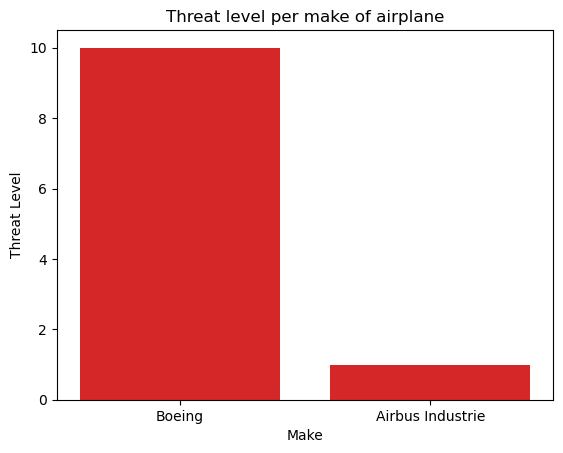

In [27]:
boeing_and_airbus_df = safe_airplanes_full_df.loc[(safe_airplanes_full_df['Make'] == 'Boeing') | (safe_airplanes_full_df['Make'] == 'Airbus Industrie')]
boeing_and_airbus_counts = boeing_and_airbus_df['Make'].value_counts()

# Plot
plot(boeing_and_airbus_counts, "Make", "Threat Level", "Threat level per make of airplane", False)

According to this plot (and the data provided), Airbus is safer than Boeing.

# 3. Conclusion and Summary

For this project, I was able to read the csv file containing accident data. EDA was then performed on the dataset discovering null values and columns of interest.

Next the dataset was trimmed to contain only airplane records. It was trimmed again in order to be left with the columns of interest. I then dropped the null values from those columns and focused on the remaining data.

Using the remaining data, I was able to identify key metrics that could help me find the safest airplanes for the company to buy. I focused on the number of accidents and incidents for each airplane as well as the number of minor injuries and uninjured.

Using these metrics I identified safe and super-safe airplanes that the company could feel confident in purchasing. I then performed some visualizations to extract key information that would be crucial for the smooth operation of the airplanes, should they be bought, and determined the safest makes and models.

In conclusion, the data extracted represents the safest airplanes from the data provided by the NTSB.

# 4. Recommendation

It is my recommendation that the company buy the airplanes highlighted in the safe and super safe CSVs with a particular focus on the `top_makes_and_models`.

Pilots using these aircraft also need to be extra-cautious during take-off and landing and when the weather is 'VMC'.